In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data (same as before)
daily = pd.read_csv('../data/processed/daily_revenue_with_intervention.csv', 
                    index_col=0, parse_dates=True)
daily = daily.asfreq('D')
daily['revenue'] = daily['revenue'].fillna(0)

print(daily.head())
print(f"\nDate range: {daily.index.min()} to {daily.index.max()}")

             revenue  revenue_original
date                                  
2010-12-01  46376.49          46376.49
2010-12-02  47316.53          47316.53
2010-12-03  23921.71          23921.71
2010-12-04      0.00              0.00
2010-12-05  31771.60          31771.60

Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00


In [2]:
intervention_date = '2011-04-01'
pre = daily[daily.index < intervention_date].copy()
post = daily[daily.index >= intervention_date].copy()

print(f"Pre-intervention days: {len(pre)}")
print(f"Post-intervention days: {len(post)}")

Pre-intervention days: 121
Post-intervention days: 253


In [3]:
# Use the last 7 days of pre period as the pattern
last_week = pre['revenue'].iloc[-7:].values
print("Last week pattern (Mon-Sun):", last_week)

# Repeat pattern to cover post period
n_repeats = int(np.ceil(len(post) / 7))
counterfactual = np.tile(last_week, n_repeats)[:len(post)]

actual = post['revenue'].values
dates = post.index

# Calculate effects
avg_actual = actual.mean()
avg_cf = counterfactual.mean()
absolute_effect = avg_actual - avg_cf
relative_effect = (absolute_effect / avg_cf) * 100

print("\n" + "="*50)
print("MAIN RESULTS (Seasonal Naive)")
print("="*50)
print(f"Average actual revenue after intervention: £{avg_actual:,.0f}")
print(f"Average counterfactual (no intervention): £{avg_cf:,.0f}")
print(f"Absolute daily effect: £{absolute_effect:,.0f}")
print(f"Relative effect: {relative_effect:.1f}%")

Last week pattern (Mon-Sun): [27302.75     0.    9224.4  20005.16 37190.52 29587.42 25688.61]

MAIN RESULTS (Seasonal Naive)
Average actual revenue after intervention: £31,905
Average counterfactual (no intervention): £21,309
Absolute daily effect: £10,596
Relative effect: 49.7%


In [4]:
# Choose a fake intervention date before the real one (e.g., Feb 1, 2011)
placebo_date = '2011-02-01'

pre_placebo = daily[daily.index < placebo_date].copy()
post_placebo = daily[(daily.index >= placebo_date) & (daily.index < intervention_date)].copy()

# Seasonal naive for placebo
last_week_placebo = pre_placebo['revenue'].iloc[-7:].values
cf_placebo = np.tile(last_week_placebo, int(np.ceil(len(post_placebo)/7)))[:len(post_placebo)]
actual_placebo = post_placebo['revenue'].values

effect_placebo = actual_placebo.mean() - cf_placebo.mean()
rel_placebo = (effect_placebo / cf_placebo.mean()) * 100

print("\n" + "="*50)
print("PLACEBO TEST (Fake intervention on 2011-02-01)")
print("="*50)
print(f"Placebo absolute effect: £{effect_placebo:,.0f}")
print(f"Placebo relative effect: {rel_placebo:.1f}%")


PLACEBO TEST (Fake intervention on 2011-02-01)
Placebo absolute effect: £2,154
Placebo relative effect: 13.9%


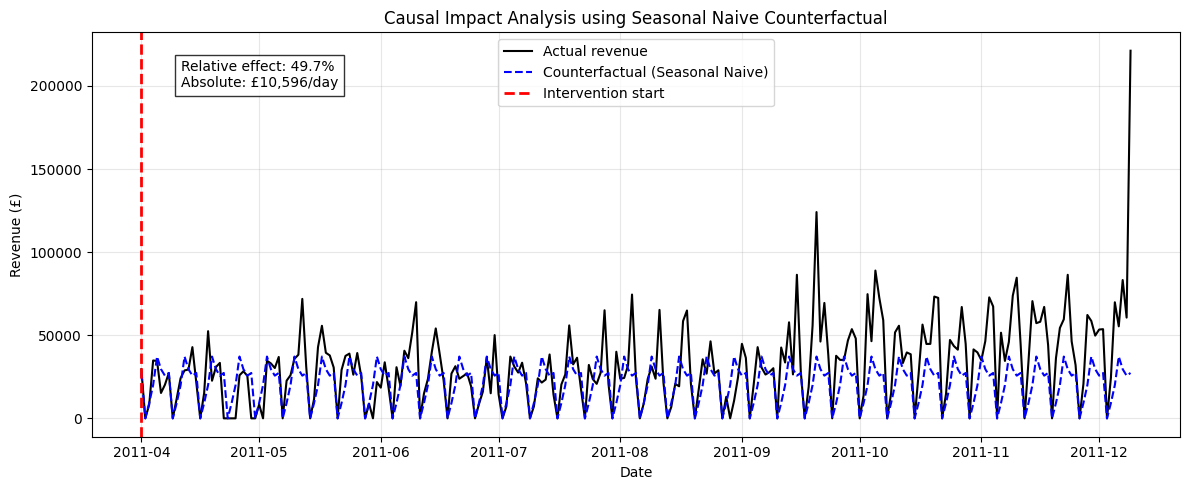

In [5]:
plt.figure(figsize=(12,5))
plt.plot(dates, actual, label='Actual revenue', color='black', linewidth=1.5)
plt.plot(dates, counterfactual, label='Counterfactual (Seasonal Naive)', color='blue', linestyle='--', linewidth=1.5)
plt.axvline(pd.Timestamp(intervention_date), color='red', linestyle='--', linewidth=2, label='Intervention start')
plt.title('Causal Impact Analysis using Seasonal Naive Counterfactual')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add effect text
plt.text(dates[10], actual.max() * 0.9, 
         f'Relative effect: {relative_effect:.1f}%\nAbsolute: £{absolute_effect:,.0f}/day',
         bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('../reports/reliable_causal_impact.png', dpi=150)
plt.show()

In [6]:
results_df = pd.DataFrame({
    'date': dates,
    'actual': actual,
    'counterfactual': counterfactual,
    'effect': actual - counterfactual
})
results_df.to_csv('../data/processed/reliable_causal_results.csv', index=False)
print("Results saved to '../data/processed/reliable_causal_results.csv'")

Results saved to '../data/processed/reliable_causal_results.csv'
